# Real-Data ProtoHedge Panel Tests - PyTorch

This notebook extends the current single-dataset real-data workflow to the new multi-ticker panel built in `Data/new-data-panel-cleaning.ipynb`.

The goal here is not only to see whether ProtoHedge works on one historical panel. The goal is to test whether the ProtoHedge tradeoff survives across multiple underlyings and market structures:

1. Load the cleaned per-ticker episode tensors.
2. Run the same robust real-data sweep for each ticker.
3. Compare vanilla Deep Hedging, ProtoHedge, and classical baselines ticker by ticker.
4. Aggregate the results across the full panel.
5. Generate paper-ready cross-ticker tables and plots.
6. Deep-dive one selected ticker with regime and prototype diagnostics.

This notebook assumes `Data/NEW_PANEL/panel_manifest.csv` already exists.


## How This Maps To The Paper

The current single-panel paper draft already supports the main claim that ProtoHedge can preserve most of vanilla Deep Hedging's performance while giving a more interpretable decision structure. This notebook is the next external-validity step: apply the same evaluation logic to a broader panel of ETFs and single-name underlyings and summarize whether the tradeoff survives across markets.


## 0. Setup

In [12]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

cwd = Path.cwd().resolve()
REPO_ROOT = cwd.parent if cwd.name == 'notebooks' else cwd
REPO_PARENT = REPO_ROOT.parent
assert (REPO_ROOT / 'world_real_torch.py').exists(), f'Could not find local repo module at {REPO_ROOT / "world_real_torch.py"}'

repo_parent_str = str(REPO_PARENT)
sys.path = [p for p in sys.path if Path(p or '.').resolve() != REPO_PARENT]
sys.path.insert(0, repo_parent_str)

for mod_name in list(sys.modules):
    if mod_name == 'deephedging' or mod_name.startswith('deephedging.'):
        del sys.modules[mod_name]

from deephedging.real_data_sweep_torch import run_real_data_sweep
from deephedging.real_data_analysis_torch import (
    evaluate_saved_artifact,
    evaluate_saved_baselines,
    build_regime_frame,
    summarize_by_regime,
    prototype_usage_table,
    prototype_usage_by_regime,
)

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)


## 1. Panel Configuration

In [13]:
PANEL_DIR = REPO_ROOT / 'Data' / 'NEW_PANEL'
MANIFEST_PATH = PANEL_DIR / 'panel_manifest.csv'
PANEL_OUTPUT_ROOT = REPO_ROOT / '.deephedging_real_runs' / 'new_data_panel'
PANEL_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
PANEL_SUMMARY_DIR = PANEL_OUTPUT_ROOT / 'panel_summary'
PANEL_SUMMARY_DIR.mkdir(parents=True, exist_ok=True)

PANEL_TICKERS = None   # None = run every processed ticker in the manifest
RUN_PANEL_SWEEP = True

# Panel-wide defaults. This notebook is configured for the paper-grade
# multi-seed cross-ticker run by default. Reduce SEEDS manually only if you
# want a faster staging run.
SEEDS = (1234, 2345, 3456)
EPOCHS = 800
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15

NORMALIZE_REAL_WORLD = True
HEDGE_MODE = 'step'
USE_POSITION_BOUNDS = True

TRADE_BOUNDS = {
    'lbnd_as': -1.0,
    'ubnd_as': 1.0,
    'lbnd_av': -1.0,
    'ubnd_av': 1.0,
}
POSITION_BOUNDS = {
    'lbnd_delta_s': -1.0,
    'ubnd_delta_s': 1.0,
    'lbnd_delta_v': -1.0,
    'ubnd_delta_v': 1.0,
}
TRAIN_SELECTION_CFG = {
    'selection_metric': 'val_loss',
    'selection_alpha_action_abs': 0.005,
    'selection_alpha_delta_abs': 0.010,
    'selection_alpha_bound_occupancy': 0.100,
    'selection_alpha_path_bound_touch': 0.0,
}
TRAIN_REG_CFG = {
    'action_penalty_weight': 0.001,
    'delta_penalty_weight': 0.002,
}
ROBUST_SCREEN_CFG = {
    'max_bound_occupancy': 0.50,
    'max_path_touch_rate': None,
}

# Cross-ticker first pass: use the current screened SPY frontier configs.
PROTOTYPE_COUNTS = (10, 25)
PROTOTYPE_SOURCES = ('spot_delta',)
WEIGHTED_SIMILARITY_OPTIONS = (False,)
LEARN_DISTANCE_FEATURE_WEIGHTS_OPTIONS = (False,)

MODEL_NAME_MAP = {
    'unhedged': 'Unhedged',
    'spot_delta': 'Spot-Delta',
    'spot_delta_band': 'Spot-Delta Band',
    'vanilla': 'Vanilla DH',
    'proto_source=spot_delta_k=10_weighted=0_learnw=0': 'ProtoHedge (Mean frontier)',
    'proto_source=spot_delta_k=25_weighted=0_learnw=0': 'ProtoHedge (Tail frontier)',
}
PANEL_MODEL_ORDER = list(MODEL_NAME_MAP)
DEEP_DIVE_TICKER = 'QQQ'

print('manifest:', MANIFEST_PATH)
print('panel output root:', PANEL_OUTPUT_ROOT)
print('seeds:', SEEDS)
print('epochs:', EPOCHS)


manifest: /Users/yaniszaim/deephedging/Data/NEW_PANEL/panel_manifest.csv
panel output root: /Users/yaniszaim/deephedging/.deephedging_real_runs/new_data_panel
seeds: (1234, 2345, 3456)
epochs: 800


## 2. Load And Validate The Panel Manifest

In [14]:
assert MANIFEST_PATH.exists(), f'Missing manifest: {MANIFEST_PATH}. Run the cleaning notebook first.'
manifest = pd.read_csv(MANIFEST_PATH)
manifest = manifest[manifest['status'] == 'ok'].copy().reset_index(drop=True)
assert not manifest.empty, 'No successfully processed tickers found in the panel manifest.'

if PANEL_TICKERS is not None:
    wanted = {str(t).upper() for t in PANEL_TICKERS}
    manifest = manifest[manifest['ticker'].isin(wanted)].copy().reset_index(drop=True)

for col in ['clean_spot_path', 'feature_path', 'episode_path']:
    manifest[col] = manifest[col].apply(lambda x: str(Path(x).resolve()))
    missing = [p for p in manifest[col] if not Path(p).exists()]
    assert not missing, f'Missing files in manifest column {col}: {missing[:3]}'

manifest


,ticker,status,spot_path,options_path,clean_spot_path,feature_path,episode_path,n_spot_rows,n_option_rows,n_feature_rows,n_episodes,feature_start_date,feature_end_date,strike_scale,n_steps,min_dte,max_dte,max_gap_days,n_gap_breaks,max_observed_gap_days
0,AAPL,ok,/Users/yaniszaim/deephedging/Data/NEW DATA/AAP...,/Users/yaniszaim/deephedging/Data/NEW DATA/AAP...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/cl...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/fe...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/ep...,5033,460033,4332,3033,2005-01-11,2024-12-31,1000.0,20,20,40,4,94,19
1,IWM,ok,/Users/yaniszaim/deephedging/Data/NEW DATA/IWM...,/Users/yaniszaim/deephedging/Data/NEW DATA/IWM...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/cl...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/fe...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/ep...,5033,755481,4505,3385,2005-01-11,2024-12-31,1000.0,20,20,40,4,69,19
2,NVDA,ok,/Users/yaniszaim/deephedging/Data/NEW DATA/NVD...,/Users/yaniszaim/deephedging/Data/NEW DATA/NVD...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/cl...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/fe...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/ep...,5033,521604,4272,2854,2005-01-11,2024-12-31,1000.0,20,20,40,4,103,19
3,QQQ,ok,/Users/yaniszaim/deephedging/Data/NEW DATA/QQQ...,/Users/yaniszaim/deephedging/Data/NEW DATA/QQQ...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/cl...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/fe...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/ep...,5033,921394,4505,3385,2005-01-11,2024-12-31,1000.0,20,20,40,4,69,19
4,SPY,ok,/Users/yaniszaim/deephedging/Data/NEW DATA/SPY...,/Users/yaniszaim/deephedging/Data/NEW DATA/SPY...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/cl...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/fe...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/ep...,5033,1426013,4505,3385,2005-01-11,2024-12-31,1000.0,20,20,40,4,69,19
5,TLT,ok,/Users/yaniszaim/deephedging/Data/NEW DATA/TLT...,/Users/yaniszaim/deephedging/Data/NEW DATA/TLT...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/cl...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/fe...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/ep...,5033,447663,4265,2846,2005-01-11,2024-12-31,1000.0,20,20,40,4,103,19
6,XLE,ok,/Users/yaniszaim/deephedging/Data/NEW DATA/XLE...,/Users/yaniszaim/deephedging/Data/NEW DATA/XLE...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/cl...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/fe...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/ep...,5033,419741,4455,3201,2005-01-11,2024-12-31,1000.0,20,20,40,4,77,19
7,XLF,ok,/Users/yaniszaim/deephedging/Data/NEW DATA/XLF...,/Users/yaniszaim/deephedging/Data/NEW DATA/XLF...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/cl...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/fe...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/ep...,5033,274542,4331,3032,2005-01-11,2024-12-31,1000.0,20,20,40,4,94,19
8,XLK,ok,/Users/yaniszaim/deephedging/Data/NEW DATA/XLK...,/Users/yaniszaim/deephedging/Data/NEW DATA/XLK...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/cl...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/fe...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/ep...,5033,369024,4265,2846,2005-01-11,2024-12-31,1000.0,20,20,40,4,103,19
9,XLV,ok,/Users/yaniszaim/deephedging/Data/NEW DATA/XLV...,/Users/yaniszaim/deephedging/Data/NEW DATA/XLV...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/cl...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/fe...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/ep...,5033,359144,4263,2830,2005-01-11,2024-12-31,1000.0,20,20,40,4,104,19


In [15]:
shape_rows = []
for _, row in manifest.iterrows():
    arr = np.load(row['episode_path'], mmap_mode='r')
    shape_rows.append({
        'ticker': row['ticker'],
        'shape': tuple(arr.shape),
        'dtype': str(arr.dtype),
        'spot0_mean': float(np.mean(arr[:, 0, 0])),
        'call_delta_mean': float(np.mean(arr[:, :, 2])),
        'ivol_mean': float(np.mean(arr[:, :, 4])),
    })
shape_df = pd.DataFrame(shape_rows)
display(shape_df)
assert all(s[1] == 20 and s[2] >= 5 for s in shape_df['shape'])


,ticker,shape,dtype,spot0_mean,call_delta_mean,ivol_mean
0,AAPL,"(3033, 20, 5)",float32,209.808624,0.517716,0.269129
1,IWM,"(3385, 20, 5)",float32,144.953720,0.516742,0.208209
2,NVDA,"(2854, 20, 5)",float32,217.486877,0.527129,0.421513
3,QQQ,"(3385, 20, 5)",float32,196.534653,0.517139,0.192937
4,SPY,"(3385, 20, 5)",float32,286.439880,0.513756,0.153908
5,TLT,"(2846, 20, 5)",float32,123.028748,0.508039,0.137550
6,XLE,"(3201, 20, 5)",float32,69.862892,0.514168,0.253469
7,XLF,"(3032, 20, 5)",float32,28.296059,0.513416,0.188976
8,XLK,"(2846, 20, 5)",float32,96.670044,0.515561,0.194249
9,XLV,"(2830, 20, 5)",float32,98.182220,0.515000,0.153776


## 3. Panel Data Diagnostics

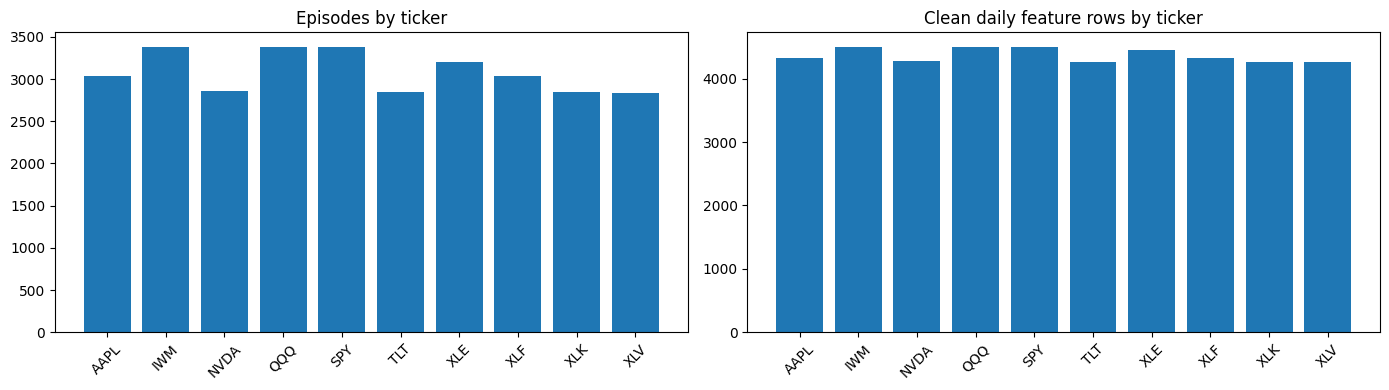

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
show = manifest.sort_values('ticker')
axes[0].bar(show['ticker'], show['n_episodes'])
axes[0].set_title('Episodes by ticker')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(show['ticker'], show['n_feature_rows'])
axes[1].set_title('Clean daily feature rows by ticker')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## 4. Run The Cross-Ticker Robust Sweeps

This section runs the same robust market/environment setup for each ticker, but uses a compact cross-ticker ProtoHedge grid based on the current SPY frontier:

- `Vanilla DH`
- `ProtoHedge (Mean frontier)`: `spot_delta`, `K=10`, unweighted
- `ProtoHedge (Tail frontier)`: `spot_delta`, `K=25`, unweighted
- plus the baseline family automatically computed by `run_real_data_sweep`

That gives a practical first paper pass across many underlyings without exploding the runtime.

In [17]:
def ticker_output_dir(ticker):
    return PANEL_OUTPUT_ROOT / f'{ticker}_frontier_800_step_robust'


def run_one_ticker(row):
    ticker = row['ticker']
    out_dir = ticker_output_dir(ticker)
    out_dir.mkdir(parents=True, exist_ok=True)
    print(f'\n===== {ticker}: running frontier sweep =====')
    metrics_df = run_real_data_sweep(
        data_path=row['episode_path'],
        output_dir=out_dir,
        samples=None,
        train_frac=TRAIN_FRAC,
        val_frac=VAL_FRAC,
        seeds=SEEDS,
        epochs=EPOCHS,
        prototype_counts=PROTOTYPE_COUNTS,
        prototype_sources=PROTOTYPE_SOURCES,
        weighted_similarity_options=WEIGHTED_SIMILARITY_OPTIONS,
        learn_distance_feature_weights_options=LEARN_DISTANCE_FEATURE_WEIGHTS_OPTIONS,
        risk_measures=('cvar',),
        normalize=NORMALIZE_REAL_WORLD,
        hedge_mode=HEDGE_MODE,
        position_bounds=USE_POSITION_BOUNDS,
        trade_bounds=TRADE_BOUNDS,
        cumulative_bounds=POSITION_BOUNDS,
        selection_metric=TRAIN_SELECTION_CFG['selection_metric'],
        selection_alpha_action_abs=TRAIN_SELECTION_CFG['selection_alpha_action_abs'],
        selection_alpha_delta_abs=TRAIN_SELECTION_CFG['selection_alpha_delta_abs'],
        selection_alpha_bound_occupancy=TRAIN_SELECTION_CFG['selection_alpha_bound_occupancy'],
        selection_alpha_path_bound_touch=TRAIN_SELECTION_CFG['selection_alpha_path_bound_touch'],
        action_penalty_weight=TRAIN_REG_CFG['action_penalty_weight'],
        delta_penalty_weight=TRAIN_REG_CFG['delta_penalty_weight'],
        max_bound_occupancy=ROBUST_SCREEN_CFG['max_bound_occupancy'],
        max_path_touch_rate=ROBUST_SCREEN_CFG['max_path_touch_rate'],
        tuned_baseline_metric='gains_mean',
    )
    return metrics_df

if RUN_PANEL_SWEEP:
    panel_metrics = {}
    for _, row in manifest.iterrows():
        panel_metrics[row['ticker']] = run_one_ticker(row)
else:
    print('RUN_PANEL_SWEEP=False, skipping sweep execution.')



===== AAPL: running frontier sweep =====

=== seed=1234 tuned spot-delta band ===
selected band=0.1000 by gains_mean

[checkpoint:seed_1234_baselines] saved 9 metric rows to /Users/yaniszaim/deephedging/.deephedging_real_runs/new_data_panel/AAPL_frontier_800_step_robust/sweep_metrics.csv

=== seed=1234 risk=cvar vanilla ===

PyTorch version 2.5.1 running on 8 CPUs and 0 GPUs
epoch 0 | batch 0.1568 | train 0.1530 | val 0.1493 | select 0.2203

[checkpoint:seed_1234_risk_cvar_vanilla] saved 12 metric rows to /Users/yaniszaim/deephedging/.deephedging_real_runs/new_data_panel/AAPL_frontier_800_step_robust/sweep_metrics.csv

=== proto_source=spot_delta_k=10_weighted=0_learnw=0 seed=1234 risk=cvar ===

PyTorch version 2.5.1 running on 8 CPUs and 0 GPUs
epoch 0 | batch 0.1614 | train 0.1572 | val 0.1528 | select 0.1771

[checkpoint:seed_1234_risk_cvar_source_spot_delta_k_10_weighted_0_learnw_0] saved 15 metric rows to /Users/yaniszaim/deephedging/.deephedging_real_runs/new_data_panel/AAPL_fro

## 5. Aggregate The Cross-Ticker Results

In [18]:
panel_rows = []
for _, row in manifest.iterrows():
    ticker = row['ticker']
    comp_path = ticker_output_dir(ticker) / 'paper_model_comparison.csv'
    best_path = ticker_output_dir(ticker) / 'paper_best_models.csv'
    assert comp_path.exists(), f'Missing expected sweep output: {comp_path}'
    comp = pd.read_csv(comp_path)
    comp = comp[comp['model'].isin(PANEL_MODEL_ORDER)].copy()
    comp['ticker'] = ticker
    comp['paper_label'] = comp['model'].map(MODEL_NAME_MAP)
    panel_rows.append(comp)

panel_df = pd.concat(panel_rows, axis=0, ignore_index=True)
panel_df = panel_df.sort_values(['ticker', 'paper_label']).reset_index(drop=True)
panel_df.to_csv(PANEL_SUMMARY_DIR / 'panel_model_metrics.csv', index=False)
print('saved:', PANEL_SUMMARY_DIR / 'panel_model_metrics.csv')

display(panel_df[['ticker', 'paper_label', 'gains_mean_avg', 'gains_mean_std', 'gains_cvar05_avg', 'shortfall_prob_avg', 'pct_at_any_position_bound_avg', 'passes_robust_screen']])


saved: /Users/yaniszaim/deephedging/.deephedging_real_runs/new_data_panel/panel_summary/panel_model_metrics.csv


,ticker,paper_label,gains_mean_avg,gains_mean_std,gains_cvar05_avg,shortfall_prob_avg,pct_at_any_position_bound_avg,passes_robust_screen
0,AAPL,ProtoHedge (Mean frontier),-0.039048,0.001742,-0.149432,0.929094,0.000768,True
1,AAPL,ProtoHedge (Tail frontier),-0.038889,0.001846,-0.147177,0.893275,0.040881,True
2,AAPL,Spot-Delta,-0.038768,0.001239,-0.149254,0.812135,0.000000,True
3,AAPL,Spot-Delta Band,-0.038764,0.001333,-0.149815,0.818713,0.000000,True
4,AAPL,Unhedged,-0.039023,0.001761,-0.153983,0.616959,0.000000,True
5,AAPL,Vanilla DH,-0.039651,0.002137,-0.148599,1.000000,0.125000,True
6,IWM,ProtoHedge (Mean frontier),-0.027329,0.000581,-0.128491,0.932547,0.002128,True
7,IWM,ProtoHedge (Tail frontier),-0.027327,0.000476,-0.127106,0.951539,0.008301,True
8,IWM,Spot-Delta,-0.027582,0.000418,-0.130486,0.812705,0.000000,True
9,IWM,Spot-Delta Band,-0.027552,0.000423,-0.129866,0.814669,0.000000,True


In [19]:
# Cross-ticker summary tables relative to vanilla.
proto_vs_vanilla = panel_df[panel_df['paper_label'].str.startswith('ProtoHedge')].copy()
proto_vs_vanilla['mean_gap_vs_vanilla'] = proto_vs_vanilla['gains_mean_avg_minus_vanilla']
proto_vs_vanilla['cvar_gap_vs_vanilla'] = proto_vs_vanilla['gains_cvar05_avg_minus_vanilla']
proto_vs_vanilla['shortfall_gap_vs_vanilla'] = proto_vs_vanilla['shortfall_prob_avg_minus_vanilla']
proto_vs_vanilla['bound_occupancy_gap_vs_vanilla'] = proto_vs_vanilla['pct_at_any_position_bound_avg'] - proto_vs_vanilla.groupby('ticker')['pct_at_any_position_bound_avg'].transform('min')
proto_vs_vanilla[['ticker', 'paper_label', 'mean_gap_vs_vanilla', 'cvar_gap_vs_vanilla', 'shortfall_gap_vs_vanilla', 'pct_at_any_position_bound_avg']]


,ticker,paper_label,mean_gap_vs_vanilla,cvar_gap_vs_vanilla,shortfall_gap_vs_vanilla,pct_at_any_position_bound_avg
0,AAPL,ProtoHedge (Mean frontier),0.000603,-0.000833,0.070906,0.000768
1,AAPL,ProtoHedge (Tail frontier),0.000762,0.001422,0.106725,0.040881
6,IWM,ProtoHedge (Mean frontier),-0.000198,-0.004635,0.010478,0.002128
7,IWM,ProtoHedge (Tail frontier),-0.000196,-0.003251,-0.008513,0.008301
12,NVDA,ProtoHedge (Mean frontier),0.003619,-0.011828,0.163947,0.324009
13,NVDA,ProtoHedge (Tail frontier),0.001234,-0.020534,0.192696,0.351865
18,QQQ,ProtoHedge (Mean frontier),-0.000353,-0.002870,-0.029470,0.010953
19,QQQ,ProtoHedge (Tail frontier),-0.000101,0.001417,0.009823,0.003847
24,SPY,ProtoHedge (Mean frontier),0.000016,0.001571,0.007859,0.037787
25,SPY,ProtoHedge (Tail frontier),-0.000209,-0.000904,0.030124,0.000000


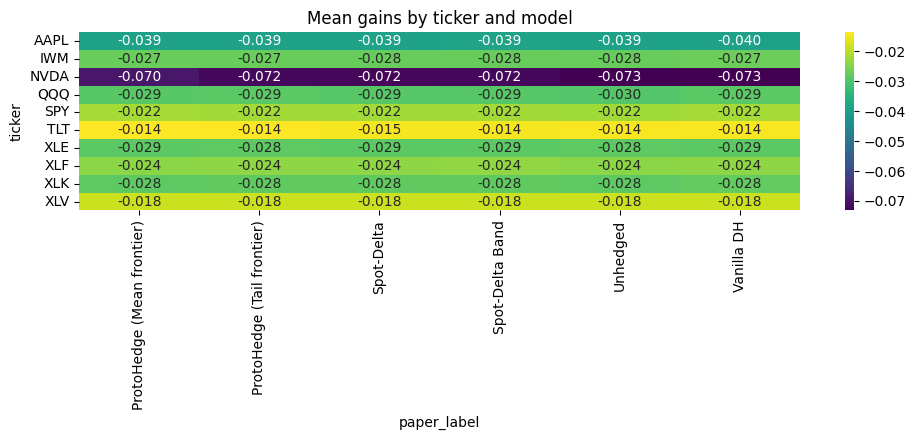

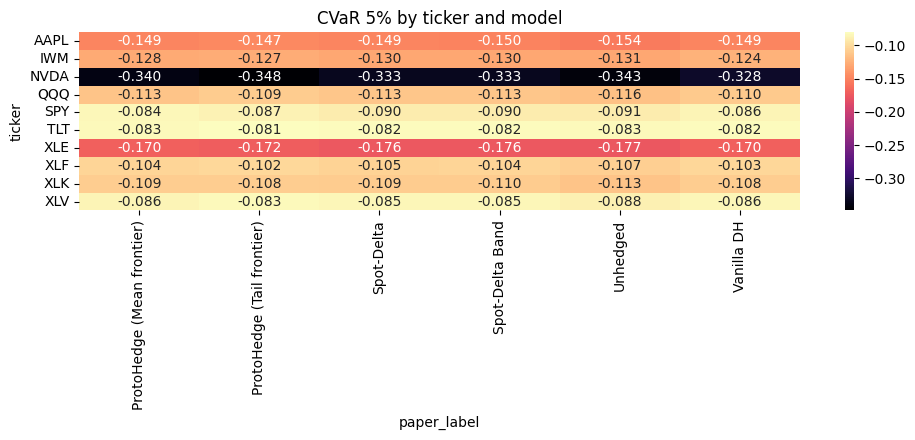

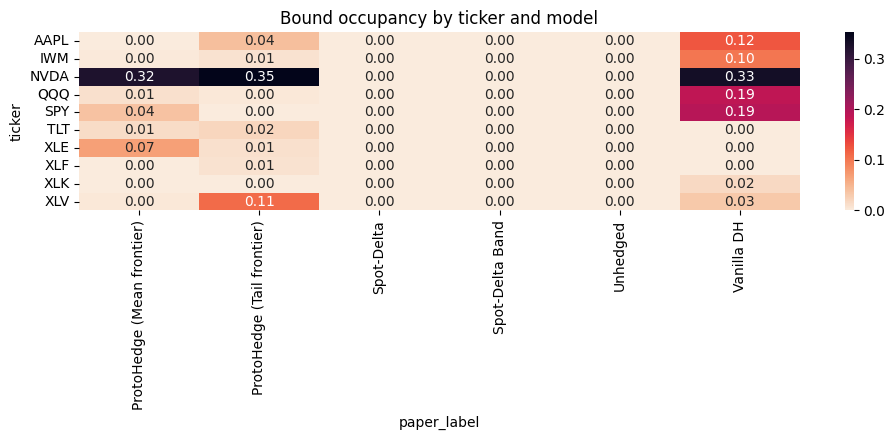

In [22]:
def metric_heatmap(metric, title, fmt='.3f', cmap='viridis'):
    pivot = panel_df.pivot(index='ticker', columns='paper_label', values=metric)
    plt.figure(figsize=(10, max(4, 0.45 * len(pivot))))
    sns.heatmap(pivot, annot=True, fmt=fmt, cmap=cmap)
    plt.title(title)
    plt.tight_layout()
    plt.show()
    return pivot

mean_pivot = metric_heatmap('gains_mean_avg', 'Mean gains by ticker and model', fmt='.3f', cmap='viridis')
cvar_pivot = metric_heatmap('gains_cvar05_avg', 'CVaR 5% by ticker and model', fmt='.3f', cmap='magma')
bound_pivot = metric_heatmap('pct_at_any_position_bound_avg', 'Bound occupancy by ticker and model', fmt='.2f', cmap='rocket_r')


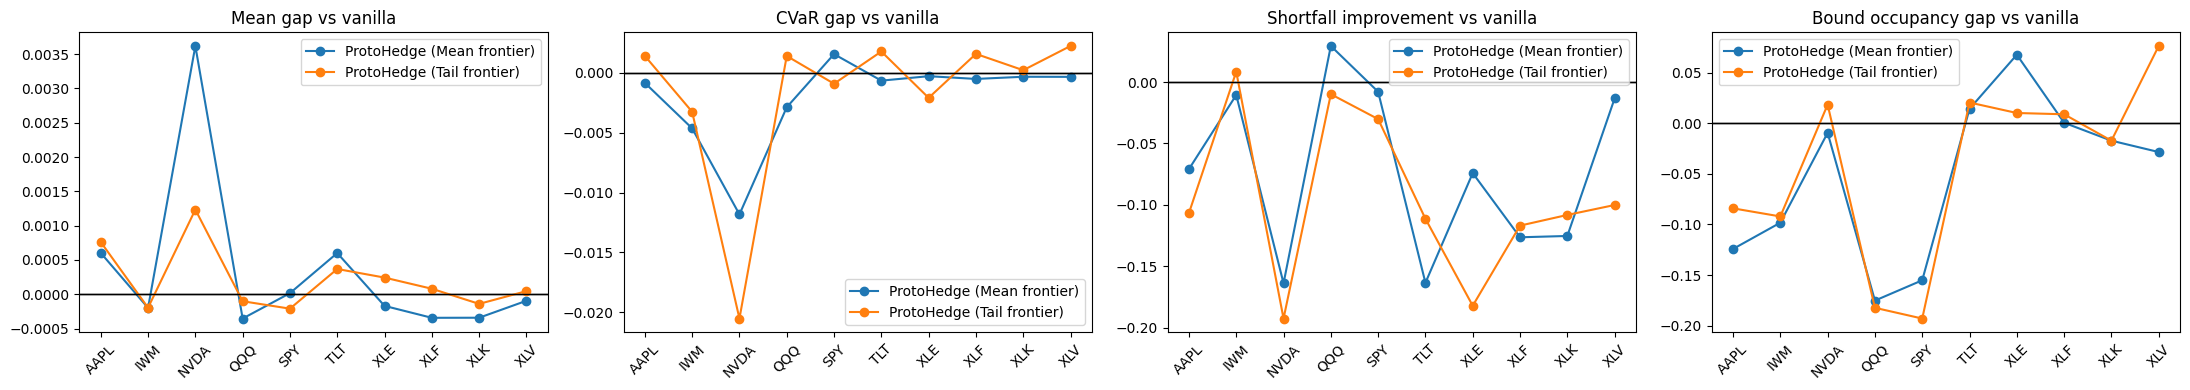

In [23]:
# ProtoHedge vs vanilla plots across tickers.
# Rebuild the gap table if needed so this cell can run on its own.
if 'panel_df' not in globals():
    panel_metrics_path = PANEL_SUMMARY_DIR / 'panel_model_metrics.csv'
    assert panel_metrics_path.exists(), f'Missing panel metrics: {panel_metrics_path}'
    panel_df = pd.read_csv(panel_metrics_path)

if 'proto_vs_vanilla' not in globals() or proto_vs_vanilla is None or len(proto_vs_vanilla) == 0:
    proto_vs_vanilla = panel_df[panel_df['paper_label'].astype(str).str.startswith('ProtoHedge')].copy()

required_gap_cols = {
    'gains_mean_avg_minus_vanilla': 'mean_gap_vs_vanilla',
    'gains_cvar05_avg_minus_vanilla': 'cvar_gap_vs_vanilla',
    'shortfall_prob_avg_minus_vanilla': 'shortfall_gap_vs_vanilla',
}

missing_precomputed = [col for col in required_gap_cols if col not in proto_vs_vanilla.columns]
if missing_precomputed:
    vanilla_ref = panel_df[panel_df['paper_label'] == 'Vanilla DH'][[
        'ticker',
        'gains_mean_avg',
        'gains_cvar05_avg',
        'shortfall_prob_avg',
        'pct_at_any_position_bound_avg',
    ]].copy()
    vanilla_ref = vanilla_ref.rename(columns={
        'gains_mean_avg': 'vanilla_gains_mean_avg',
        'gains_cvar05_avg': 'vanilla_gains_cvar05_avg',
        'shortfall_prob_avg': 'vanilla_shortfall_prob_avg',
        'pct_at_any_position_bound_avg': 'vanilla_pct_at_any_position_bound_avg',
    })
    proto_vs_vanilla = proto_vs_vanilla.drop(columns=[c for c in vanilla_ref.columns if c in proto_vs_vanilla.columns and c != 'ticker'], errors='ignore')
    proto_vs_vanilla = proto_vs_vanilla.merge(vanilla_ref, on='ticker', how='left', validate='many_to_one')
    proto_vs_vanilla['mean_gap_vs_vanilla'] = proto_vs_vanilla['gains_mean_avg'] - proto_vs_vanilla['vanilla_gains_mean_avg']
    proto_vs_vanilla['cvar_gap_vs_vanilla'] = proto_vs_vanilla['gains_cvar05_avg'] - proto_vs_vanilla['vanilla_gains_cvar05_avg']
    proto_vs_vanilla['shortfall_gap_vs_vanilla'] = proto_vs_vanilla['vanilla_shortfall_prob_avg'] - proto_vs_vanilla['shortfall_prob_avg']
    proto_vs_vanilla['bound_occupancy_gap_vs_vanilla'] = proto_vs_vanilla['pct_at_any_position_bound_avg'] - proto_vs_vanilla['vanilla_pct_at_any_position_bound_avg']
else:
    proto_vs_vanilla['mean_gap_vs_vanilla'] = proto_vs_vanilla['gains_mean_avg_minus_vanilla']
    proto_vs_vanilla['cvar_gap_vs_vanilla'] = proto_vs_vanilla['gains_cvar05_avg_minus_vanilla']
    proto_vs_vanilla['shortfall_gap_vs_vanilla'] = -proto_vs_vanilla['shortfall_prob_avg_minus_vanilla']
    vanilla_occ = panel_df[panel_df['paper_label'] == 'Vanilla DH'][['ticker', 'pct_at_any_position_bound_avg']].rename(
        columns={'pct_at_any_position_bound_avg': 'vanilla_pct_at_any_position_bound_avg'}
    )
    proto_vs_vanilla = proto_vs_vanilla.drop(columns=['vanilla_pct_at_any_position_bound_avg'], errors='ignore')
    proto_vs_vanilla = proto_vs_vanilla.merge(vanilla_occ, on='ticker', how='left', validate='many_to_one')
    proto_vs_vanilla['bound_occupancy_gap_vs_vanilla'] = proto_vs_vanilla['pct_at_any_position_bound_avg'] - proto_vs_vanilla['vanilla_pct_at_any_position_bound_avg']

proto_vs_vanilla = proto_vs_vanilla.sort_values(['paper_label', 'ticker']).reset_index(drop=True)

ticker_order = sorted(proto_vs_vanilla['ticker'].unique())
fig, axes = plt.subplots(1, 4, figsize=(22, 4))
plot_specs = [
    ('mean_gap_vs_vanilla', 'Mean gap vs vanilla'),
    ('cvar_gap_vs_vanilla', 'CVaR gap vs vanilla'),
    ('shortfall_gap_vs_vanilla', 'Shortfall improvement vs vanilla'),
    ('bound_occupancy_gap_vs_vanilla', 'Bound occupancy gap vs vanilla'),
]
for label, grp in proto_vs_vanilla.groupby('paper_label'):
    grp = grp.set_index('ticker').reindex(ticker_order).reset_index()
    for ax, (metric, title) in zip(axes, plot_specs):
        ax.plot(grp['ticker'], grp[metric], marker='o', label=label)
        ax.axhline(0.0, color='black', lw=1)
        ax.set_title(title)
        ax.tick_params(axis='x', rotation=45)

for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()


The heatmaps above answer the broad paper question: does the ProtoHedge tradeoff generalize across underlyings? The first figure shows raw performance, the second highlights downside behavior, and the third shows whether a model leans heavily on hard position bounds. The line plots then recast the same information as explicit ProtoHedge-versus-vanilla gaps ticker by ticker.


## 6. Panel-Wide Paper Tables

In [24]:
# Build the panel-wide paper table.
# Reload the saved summary if this cell is run out of order.
if 'panel_df' not in globals():
    panel_metrics_path = PANEL_SUMMARY_DIR / 'panel_model_metrics.csv'
    assert panel_metrics_path.exists(), f'Missing panel metrics: {panel_metrics_path}'
    panel_df = pd.read_csv(panel_metrics_path)

panel_df = panel_df.copy()
if 'passes_robust_screen' not in panel_df.columns:
    if {'passes_bound_occupancy_screen', 'passes_path_touch_screen'}.issubset(panel_df.columns):
        panel_df['passes_robust_screen'] = (
            panel_df['passes_bound_occupancy_screen'].fillna(True)
            & panel_df['passes_path_touch_screen'].fillna(True)
        )
    else:
        panel_df['passes_robust_screen'] = True

keep_cols = [
    'ticker',
    'paper_label',
    'gains_mean_avg',
    'gains_mean_std',
    'gains_cvar05_avg',
    'shortfall_prob_avg',
    'pct_at_any_position_bound_avg',
    'passes_robust_screen',
]
missing = [c for c in keep_cols if c not in panel_df.columns]
assert not missing, f'Missing expected panel columns: {missing}'

panel_main = panel_df[keep_cols].copy()
panel_main = panel_main.sort_values(['ticker', 'paper_label']).reset_index(drop=True)
panel_main.to_csv(PANEL_SUMMARY_DIR / 'panel_main_table.csv', index=False)
print('saved:', PANEL_SUMMARY_DIR / 'panel_main_table.csv')

display(panel_main)


saved: /Users/yaniszaim/deephedging/.deephedging_real_runs/new_data_panel/panel_summary/panel_main_table.csv


,ticker,paper_label,gains_mean_avg,gains_mean_std,gains_cvar05_avg,shortfall_prob_avg,pct_at_any_position_bound_avg,passes_robust_screen
0,AAPL,ProtoHedge (Mean frontier),-0.039048,0.001742,-0.149432,0.929094,0.000768,True
1,AAPL,ProtoHedge (Tail frontier),-0.038889,0.001846,-0.147177,0.893275,0.040881,True
2,AAPL,Spot-Delta,-0.038768,0.001239,-0.149254,0.812135,0.000000,True
3,AAPL,Spot-Delta Band,-0.038764,0.001333,-0.149815,0.818713,0.000000,True
4,AAPL,Unhedged,-0.039023,0.001761,-0.153983,0.616959,0.000000,True
5,AAPL,Vanilla DH,-0.039651,0.002137,-0.148599,1.000000,0.125000,True
6,IWM,ProtoHedge (Mean frontier),-0.027329,0.000581,-0.128491,0.932547,0.002128,True
7,IWM,ProtoHedge (Tail frontier),-0.027327,0.000476,-0.127106,0.951539,0.008301,True
8,IWM,Spot-Delta,-0.027582,0.000418,-0.130486,0.812705,0.000000,True
9,IWM,Spot-Delta Band,-0.027552,0.000423,-0.129866,0.814669,0.000000,True


## 7. Single-Ticker Deep Dive

In [25]:
if DEEP_DIVE_TICKER not in set(manifest['ticker']):
    DEEP_DIVE_TICKER = manifest.iloc[0]['ticker']

print('deep dive ticker:', DEEP_DIVE_TICKER)
deep_dir = ticker_output_dir(DEEP_DIVE_TICKER)
deep_metrics = pd.read_csv(deep_dir / 'sweep_metrics.csv')
deep_summary = pd.read_csv(deep_dir / 'sweep_test_summary.csv')

deep_summary = deep_summary[deep_summary['model'].isin(PANEL_MODEL_ORDER)].copy()
display(deep_summary[['model', 'gains_mean_avg', 'gains_cvar05_avg', 'shortfall_prob_avg', 'pct_at_any_position_bound_avg']])


deep dive ticker: QQQ


,model,gains_mean_avg,gains_cvar05_avg,shortfall_prob_avg,pct_at_any_position_bound_avg
0,vanilla,-0.028783,-0.110270,0.915521,0.186182
1,proto_source=spot_delta_k=25_weighted=0_learnw=0,-0.028884,-0.108852,0.905697,0.003847
2,proto_source=spot_delta_k=10_weighted=0_learnw=0,-0.029136,-0.113139,0.944990,0.010953
3,spot_delta,-0.029252,-0.112778,0.861821,0.000000
4,spot_delta_band,-0.029253,-0.112823,0.860511,0.000000
5,unhedged,-0.029561,-0.115993,0.712508,0.000000


In [26]:
# Use the tail frontier artifact for interpretability and regime diagnostics by default.
TARGET_MODEL = 'proto_source=spot_delta_k=25_weighted=0_learnw=0'
artifact_rows = deep_metrics[(deep_metrics['model'] == TARGET_MODEL) & (deep_metrics['split'] == 'test')].copy()
assert not artifact_rows.empty, f'Could not find artifact rows for {TARGET_MODEL}'
artifact_dir = Path(artifact_rows.iloc[0]['artifact_dir'])
print('artifact:', artifact_dir)

bundle, proto_result, proto_metrics = evaluate_saved_artifact(artifact_dir, split='test')
baselines = evaluate_saved_baselines(artifact_dir, split='test')
vanilla_rows = deep_metrics[(deep_metrics['model'] == 'vanilla') & (deep_metrics['split'] == 'test')].copy()
vanilla_artifact_dir = Path(vanilla_rows.iloc[0]['artifact_dir'])
vanilla_bundle, vanilla_result, vanilla_metrics = evaluate_saved_artifact(vanilla_artifact_dir, split='test')

result_dict = {
    'proto_tail': proto_result,
    'vanilla': vanilla_result,
    'spot_delta_band': baselines['spot_delta_band']['result'],
    'unhedged': baselines['unhedged']['result'],
}
regime_frame = build_regime_frame(bundle['eval_world'], result_dict)
regime_summary = pd.concat([
    summarize_by_regime(regime_frame, 'return_regime'),
    summarize_by_regime(regime_frame, 'vol_regime'),
    summarize_by_regime(regime_frame, 'drawdown_regime'),
], axis=0, ignore_index=True)
regime_summary.to_csv(PANEL_SUMMARY_DIR / f'{DEEP_DIVE_TICKER}_regime_summary.csv', index=False)
print('saved:', PANEL_SUMMARY_DIR / f'{DEEP_DIVE_TICKER}_regime_summary.csv')
regime_summary.head()


artifact: /Users/yaniszaim/deephedging/.deephedging_real_runs/new_data_panel/QQQ_frontier_800_step_robust/model_artifacts/seed_1234/risk_cvar/proto_source_spot_delta_k_25_weighted_0_learnw_0
saved: /Users/yaniszaim/deephedging/.deephedging_real_runs/new_data_panel/panel_summary/QQQ_regime_summary.csv


/Users/yaniszaim/deephedging/real_data_analysis_torch.py:98: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(artifact_dir / ARTIFACT_STATE, map_locatio

,regime_type,regime,series,n,mean,p05,cvar05,shortfall_prob
0,return_regime,down,proto_tail_gains,170,-0.002390,-0.010948,-0.012505,0.700000
1,return_regime,down,vanilla_gains,170,-0.002602,-0.008406,-0.009983,0.741176
2,return_regime,down,spot_delta_band_gains,170,-0.001949,-0.011593,-0.016155,0.647059
3,return_regime,down,unhedged_gains,170,-0.000850,-0.005891,-0.008167,0.194118
4,return_regime,middle,proto_tail_gains,169,-0.023789,-0.035646,-0.038793,1.000000


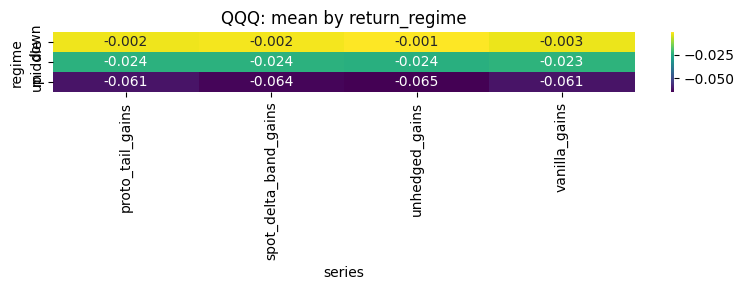

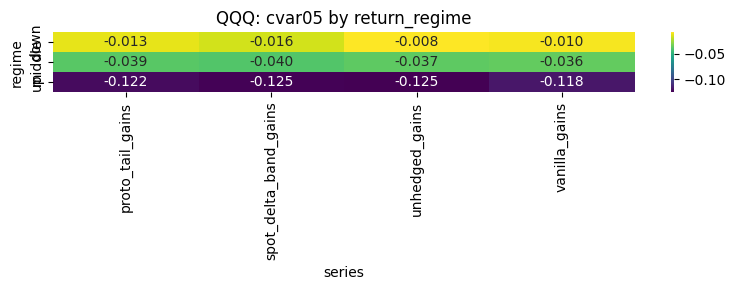

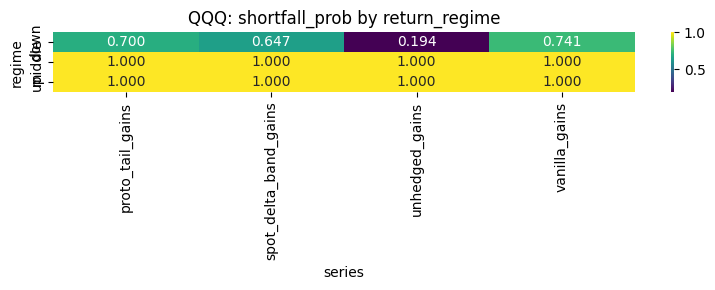

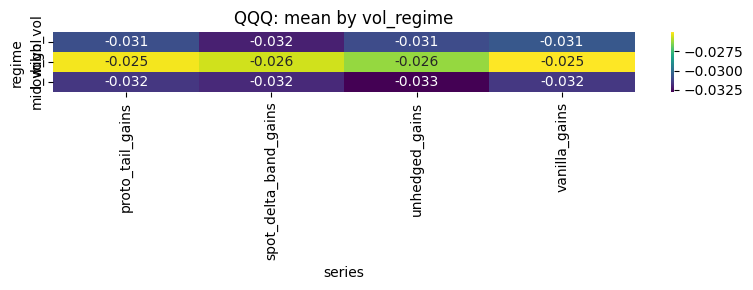

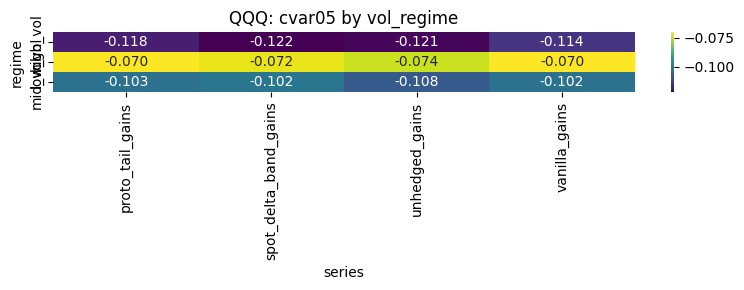

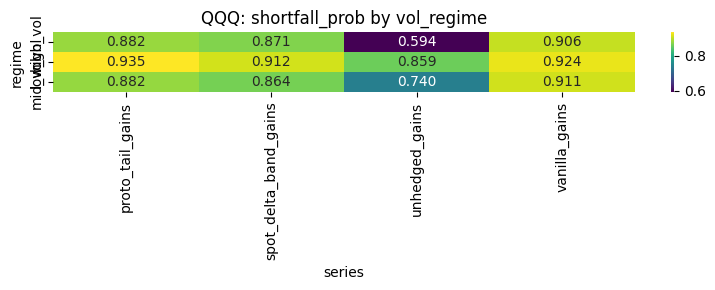

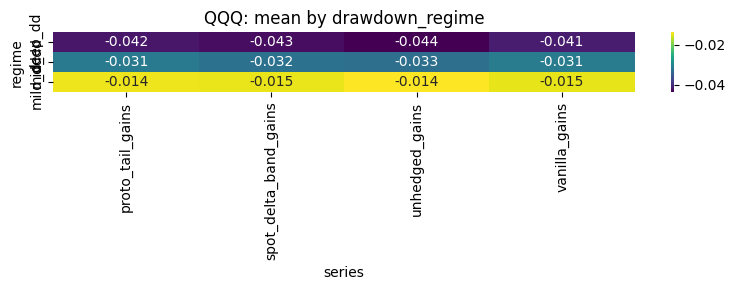

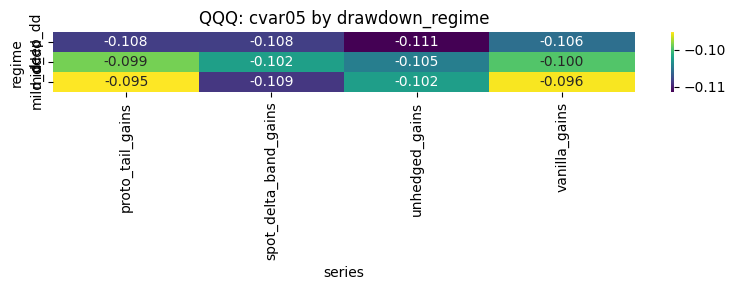

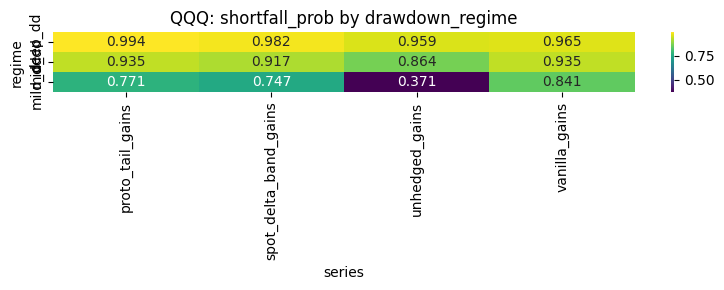

In [27]:
# Deep-dive regime heatmaps.
for regime_type in ['return_regime', 'vol_regime', 'drawdown_regime']:
    sub = regime_summary[regime_summary['regime_type'] == regime_type].copy()
    for metric in ['mean', 'cvar05', 'shortfall_prob']:
        pivot = sub.pivot(index='regime', columns='series', values=metric)
        plt.figure(figsize=(8, 3))
        sns.heatmap(pivot, annot=True, fmt='.3f', cmap='viridis')
        plt.title(f'{DEEP_DIVE_TICKER}: {metric} by {regime_type}')
        plt.tight_layout()
        plt.show()


In [28]:
top_proto_df, full_proto_df = prototype_usage_table(bundle, proto_result, top_n=10)
usage_by_regime_df = prototype_usage_by_regime(proto_result, regime_frame)

top_proto_df.to_csv(PANEL_SUMMARY_DIR / f'{DEEP_DIVE_TICKER}_prototype_top10.csv', index=False)
usage_by_regime_df.to_csv(PANEL_SUMMARY_DIR / f'{DEEP_DIVE_TICKER}_prototype_usage_by_regime.csv', index=False)
print('saved prototype tables for', DEEP_DIVE_TICKER)
display(top_proto_df)


saved prototype tables for QQQ


,prototype_index,usage_mean,top1_frequency,delta_0,delta_1,price_0,price_1,time_left,proto_action_0,proto_action_1
0,8,0.250704,0.276621,5.152600e-01,0.0,1.044062,0.016025,0.06,0.054056,2.187490e-05
1,16,0.229304,0.308448,5.220810e-01,0.0,1.020023,0.023449,0.08,-0.108916,2.424121e-04
2,10,0.188335,0.135265,5.050130e-01,0.0,1.009169,0.015359,0.06,0.295132,1.719594e-04
3,18,0.112071,0.113065,5.223480e-01,0.0,0.975986,0.021213,0.08,-0.056871,-5.745888e-05
4,23,0.052714,0.041552,5.163680e-01,0.0,0.947908,0.028562,0.08,-0.003832,-8.869171e-05
5,21,0.041884,0.041847,5.339550e-01,0.0,0.858115,0.059791,0.14,0.191163,-2.714276e-02
6,4,0.039051,0.021513,5.201090e-01,0.0,1.017422,0.036325,0.10,-0.038553,1.701713e-04
7,3,0.035210,0.029666,5.209370e-01,0.0,0.897556,0.034479,0.10,0.047281,-1.192093e-07
8,2,0.024184,0.022790,-1.755054e-08,0.0,1.000000,0.033063,0.40,0.046833,6.103516e-05
9,17,0.012738,0.005599,5.227650e-01,0.0,1.070692,0.023937,0.08,-0.293260,-7.867813e-06


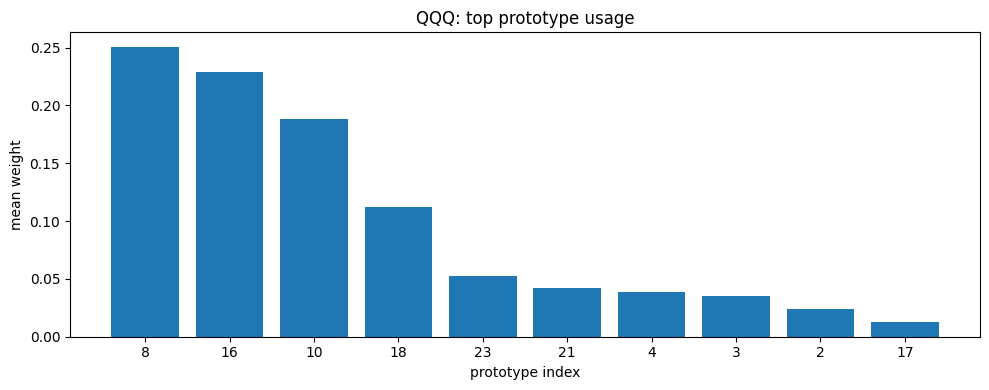

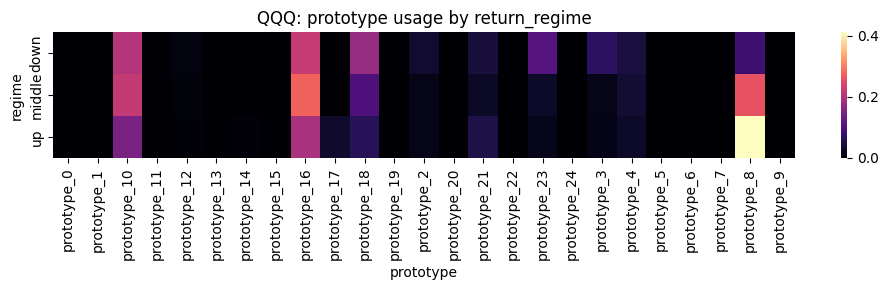

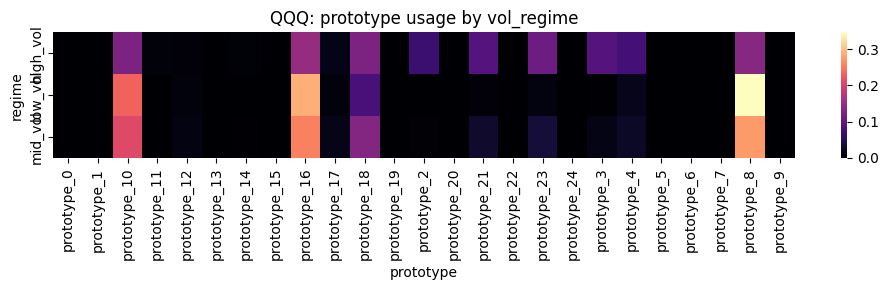

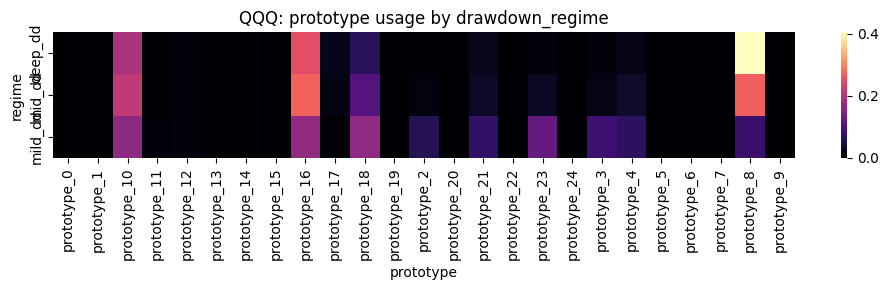

In [29]:
plt.figure(figsize=(10, 4))
plot_df = top_proto_df.sort_values('usage_mean', ascending=False).head(10)
plt.bar(plot_df['prototype_index'].astype(str), plot_df['usage_mean'])
plt.title(f'{DEEP_DIVE_TICKER}: top prototype usage')
plt.xlabel('prototype index')
plt.ylabel('mean weight')
plt.tight_layout()
plt.show()

for regime_type in ['return_regime', 'vol_regime', 'drawdown_regime']:
    sub = usage_by_regime_df[usage_by_regime_df['regime_type'] == regime_type].copy()
    pivot = sub.pivot(index='regime', columns='prototype', values='mean_weight')
    plt.figure(figsize=(10, 3))
    sns.heatmap(pivot, annot=False, cmap='magma')
    plt.title(f'{DEEP_DIVE_TICKER}: prototype usage by {regime_type}')
    plt.tight_layout()
    plt.show()


This deep-dive section mirrors the last part of the current single-dataset notebook, but uses one ticker from the new panel. The idea is simple: the panel-wide sweep tells us whether the ProtoHedge tradeoff survives across markets, while the deep-dive section gives us the ticker-level regime and prototype evidence needed for the paper's interpretability discussion.
